In [1]:
# === MEMORY-EFFICIENT DATA LOADING: ALL INDIVIDUAL MEASUREMENTS ===
print("="*70)
print("MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS")
print("="*70)

import os
import h5py
import re
import pandas as pd
import numpy as np
import gc  # Garbage collection for memory management

def extract_tire_number(filename):
    """Extract tire number from filename"""
    match = re.search(r'_B(\d+)_', filename)
    if match:
        return int(match.group(1))
    else:
        match = re.search(r'nr-(\d+)', filename)
        if match:
            return int(match.group(1))
    return None

def process_file_generator(data_directory, max_files=None):
    """
    Generator that yields individual measurements one at a time
    More memory efficient than storing all in memory
    """
    all_files = [f for f in os.listdir(data_directory) if f.endswith('.h5')]
    if max_files:
        all_files = all_files[:max_files]
    
    total_measurements = 0
    wavelength_reference = None  # Store wavelength array once
    
    for i, filename in enumerate(all_files):
        if i % 10 == 0:
            print(f"Processing file {i+1}/{len(all_files)}: {filename}")
        
        try:
            filepath = os.path.join(data_directory, filename)
            tire_number = extract_tire_number(filename)
            
            if tire_number is None:
                continue
            
            # Determine origin from filename
            if "tread" in filename.lower():
                origin = 'tread'
            elif "innerliner" in filename.lower():
                origin = 'innerliner'
            elif "sidewall" in filename.lower():
                origin = 'sidewall'
            else:
                continue
            
            # Load HDF5 file efficiently
            with h5py.File(filepath, 'r') as h5:
                intensity = h5['intensity'][:]
                wavelength = h5['wavelength'][:]
                
                # Store wavelength reference only once
                if wavelength_reference is None:
                    wavelength_reference = wavelength.copy()
                
                # Process measurements
                if intensity.ndim == 2:
                    n_measurements, n_wavelengths = intensity.shape
                    
                    # Yield each measurement individually
                    for measurement_idx in range(n_measurements):
                        measurement_data = {
                            'tire_number': tire_number,
                            'origin': origin,
                            'measurement_id': measurement_idx,
                            'intensities': intensity[measurement_idx, :].astype(np.float32),  # Use float32 to save memory
                        }
                        yield measurement_data
                        total_measurements += 1
                else:
                    # Single measurement case
                    measurement_data = {
                        'tire_number': tire_number,
                        'origin': origin,
                        'measurement_id': 0,
                        'intensities': intensity.astype(np.float32),
                    }
                    yield measurement_data
                    total_measurements += 1
                    
        except Exception as e:
            print(f"  Error processing {filename}: {e}")
            continue
    
    print(f"Total measurements processed: {total_measurements:,}")

# Memory-efficient data loading
data_directory = 'data'
all_files = [f for f in os.listdir(data_directory) if f.endswith('.h5')]
print(f"Found {len(all_files)} HDF5 files")

# Use all files (remove max_files limit for full dataset)
print("Processing ALL files for maximum dataset size...")

# Initialize data containers with pre-allocation
print("Initializing memory-efficient data structures...")

# First pass: count total measurements and get wavelength info
measurement_count = 0
wavelength_info = None

print("First pass: Counting measurements...")
for measurement in process_file_generator(data_directory):
    measurement_count += 1
    if wavelength_info is None:
        n_wavelengths = len(measurement['intensities'])
        wavelength_info = n_wavelengths
    
    # Progress tracking
    if measurement_count % 10000 == 0:
        print(f"  Counted {measurement_count:,} measurements...")

print(f"Total measurements found: {measurement_count:,}")
print(f"Wavelengths per spectrum: {wavelength_info}")

# Pre-allocate numpy arrays for maximum memory efficiency
print("Pre-allocating memory-efficient arrays...")
X_data = np.empty((measurement_count, wavelength_info), dtype=np.float32)
y_data = np.empty(measurement_count, dtype='U10')  # String array for origins
metadata = np.empty((measurement_count, 2), dtype=np.int32)  # tire_number, measurement_id

# Second pass: fill the arrays
print("Second pass: Loading data into arrays...")
idx = 0
for measurement in process_file_generator(data_directory):
    X_data[idx] = measurement['intensities']
    y_data[idx] = measurement['origin']
    metadata[idx, 0] = measurement['tire_number']
    metadata[idx, 1] = measurement['measurement_id']
    
    idx += 1
    
    # Progress tracking and memory cleanup
    if idx % 10000 == 0:
        print(f"  Loaded {idx:,}/{measurement_count:,} measurements ({idx/measurement_count*100:.1f}%)")
        gc.collect()  # Force garbage collection

# Create DataFrame efficiently
print("Creating final DataFrame...")
wavelength_columns = [f'{wl:.3f}' for wl in np.linspace(200, 1000, wavelength_info)]  # Approximate wavelength range

# Create DataFrame with pre-allocated data
df_individual = pd.DataFrame(X_data, columns=wavelength_columns, dtype=np.float32)
df_individual['origin'] = y_data
df_individual['tire_number'] = metadata[:, 0]  
df_individual['measurement_id'] = metadata[:, 1]

# Clean up intermediate arrays
del X_data, y_data, metadata
gc.collect()

file_count = len([f for f in all_files if extract_tire_number(f) is not None])

print(f"\n" + "="*70)
print("MEMORY-EFFICIENT DATASET CREATED")
print("="*70)
print(f"Total measurements: {len(df_individual):,}")
print(f"Files processed: {file_count}")
print(f"Dataset shape: {df_individual.shape}")
print(f"Memory usage: {df_individual.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Analyze the dataset
print(f"\nDataset analysis:")
print(f"Unique tire numbers: {df_individual['tire_number'].nunique()}")
print(f"Origins distribution:")
print(df_individual['origin'].value_counts())

print(f"\nMeasurements per tire-origin combination:")
measurements_per_combo = df_individual.groupby(['tire_number', 'origin']).size()
print(f"Average: {measurements_per_combo.mean():.1f}")
print(f"Min: {measurements_per_combo.min()}")
print(f"Max: {measurements_per_combo.max()}")

# Identify wavelength columns (now they're numeric)
wavelength_columns = [col for col in df_individual.columns if col not in ['origin', 'tire_number', 'measurement_id']]
print(f"\nWavelength features: {len(wavelength_columns)}")

print(f"\nSample of first few rows:")
display_cols = ['tire_number', 'origin', 'measurement_id'] + wavelength_columns[:5]
print(df_individual[display_cols].head())

print(f"\nExpected vs Actual samples:")
expected_per_file = 254  # Based on your observation
total_expected = file_count * expected_per_file
actual_samples = len(df_individual)
print(f"Expected (254 × {file_count} files): {total_expected:,}")
print(f"Actual samples: {actual_samples:,}")
print(f"Sample utilization: {actual_samples/total_expected:.1%}")

# This approach gives us MUCH more data!
print(f"\n🚀 MEMORY-EFFICIENT FULL DATASET:")
print(f"   Previous approach (limited): ~2,540 samples")
print(f"   New approach (full dataset): {actual_samples:,} samples")
print(f"   Improvement: {actual_samples/2540:.0f}x more data!")
print(f"   Memory efficient: Using float32 and pre-allocation")
print(f"   Processing: Generator-based streaming")

# Memory optimization summary
print(f"\n💾 MEMORY OPTIMIZATIONS APPLIED:")
print("   ✅ Generator-based file processing (streaming)")
print("   ✅ Pre-allocated numpy arrays")
print("   ✅ float32 instead of float64 (50% memory saving)")
print("   ✅ Periodic garbage collection")
print("   ✅ Direct array-to-DataFrame conversion")
print("   ✅ Efficient string arrays for categorical data")

print(f"\n🎯 DATASET READY FOR MACHINE LEARNING:")
print(f"   • Full dataset: {actual_samples:,} individual measurements")
print(f"   • Memory usage: {df_individual.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   • Data type: Optimized float32")
print(f"   • Ready for: Classification, LDA, baseline correction")

MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
Found 316 HDF5 files
Processing ALL files for maximum dataset size...
Initializing memory-efficient data structures...
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Found 316 HDF5 files
Processing ALL files for maximum dataset size...
Initializing memory-efficient data structures...
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerline

In [2]:
# === PREPARE INDIVIDUAL MEASUREMENTS FOR MACHINE LEARNING ===
print("\n" + "="*70)
print("PREPARING INDIVIDUAL MEASUREMENTS FOR ML")
print("="*70)

# Check what columns actually exist in df_individual
print(f"Available columns in df_individual: {list(df_individual.columns)[:10]}...")  # Show first 10 columns
print(f"Total columns: {len(df_individual.columns)}")

# Separate features and target from individual measurements
# Only include columns that actually exist
existing_meta_columns = ['tire_number', 'origin', 'measurement_id']
meta_columns = [col for col in existing_meta_columns if col in df_individual.columns]

# Find wavelength columns - they are numeric column names (not prefixed with 'wl_')
numeric_columns = [col for col in df_individual.columns if isinstance(col, (int, float)) or 
                  (isinstance(col, str) and col.replace('.', '').replace('-', '').isdigit())]
wavelength_columns = [col for col in numeric_columns if col not in meta_columns]

print(f"Meta columns found: {meta_columns}")
print(f"Wavelength features found: {len(wavelength_columns)}")

# Create ML-ready dataset
X_individual = df_individual[wavelength_columns].copy()
y_individual = df_individual['origin'].copy()

# Column mapping is not needed since columns are already numeric wavelength values
column_mapping = {}

X_individual = X_individual.rename(columns=column_mapping)

print(f"Feature matrix shape: {X_individual.shape}")
print(f"Target distribution:\n{y_individual.value_counts()}")

# Handle any missing or infinite values
print(f"\nData quality check:")
missing_count = X_individual.isnull().sum().sum()
print(f"Missing values: {missing_count}")

if missing_count > 0:
    print("Filling missing values with column means...")
    X_individual = X_individual.fillna(X_individual.mean())

# Check for infinite values
inf_count = np.isinf(X_individual.values).sum()
print(f"Infinite values: {inf_count}")

if inf_count > 0:
    print("Replacing infinite values with column means...")
    X_individual = X_individual.replace([np.inf, -np.inf], np.nan).fillna(X_individual.mean())

# Add metadata for reference
df_individual_ml = df_individual[meta_columns].copy()
df_individual_ml = pd.concat([df_individual_ml, X_individual], axis=1)
df_individual_ml['origin'] = y_individual

print(f"\nFinal ML dataset shape: {df_individual_ml.shape}")
print(f"Samples available: {len(df_individual_ml):,}")

# Split the data with stratification to ensure balanced train/test sets
from sklearn.model_selection import train_test_split

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X_individual, y_individual, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_individual
)

print(f"\nTrain/Test split:")
print(f"Training set: {X_train_ind.shape}")
print(f"Test set: {X_test_ind.shape}")

print(f"\nTraining set distribution:")
print(y_train_ind.value_counts())

print(f"\nTest set distribution:")
print(y_test_ind.value_counts())

print(f"\n✅ INDIVIDUAL MEASUREMENTS DATASET READY FOR ML!")
print(f"   • {len(df_individual_ml):,} individual spectral measurements")
print(f"   • {len(wavelength_columns)} wavelength features")  
print(f"   • Perfect for advanced ML models")
print(f"   • Much better than averaged data!")


PREPARING INDIVIDUAL MEASUREMENTS FOR ML
Available columns in df_individual: ['200.000', '200.098', '200.195', '200.293', '200.391', '200.489', '200.586', '200.684', '200.782', '200.879']...
Total columns: 8191
Meta columns found: ['tire_number', 'origin', 'measurement_id']
Wavelength features found: 8188
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Data quality check:
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Data quality check:
Missing values: 0
Missing values: 0
Infinite values: 0
Infinite values: 0

Final ML dataset shape: (51453, 8191)
Samples available: 51,453

Final ML dataset shape: (51453, 8191)
Samples available: 51,453

Train/Test split:
Training set: (41162, 8188)
Test set: (10291, 8188)

Training set distribution:
origin
tread         14349
innerliner    13808



LDA ANALYSIS WITH INDIVIDUAL MEASUREMENTS
Maximum LDA components for 3 classes: 2
Maximum LDA components for 3 classes: 2
Original feature space: 8188 wavelengths
Reduced feature space: 2 LDA components
Dimensionality reduction: 100.0%
Explained variance ratio: [0.6305241  0.36947596]
Total explained variance: 1.0000
Sampling 5000 points for visualization from 41162 total
Original feature space: 8188 wavelengths
Reduced feature space: 2 LDA components
Dimensionality reduction: 100.0%
Explained variance ratio: [0.6305241  0.36947596]
Total explained variance: 1.0000
Sampling 5000 points for visualization from 41162 total


C:\Users\joost\AppData\Local\Temp\ipykernel_22304\93421582.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)


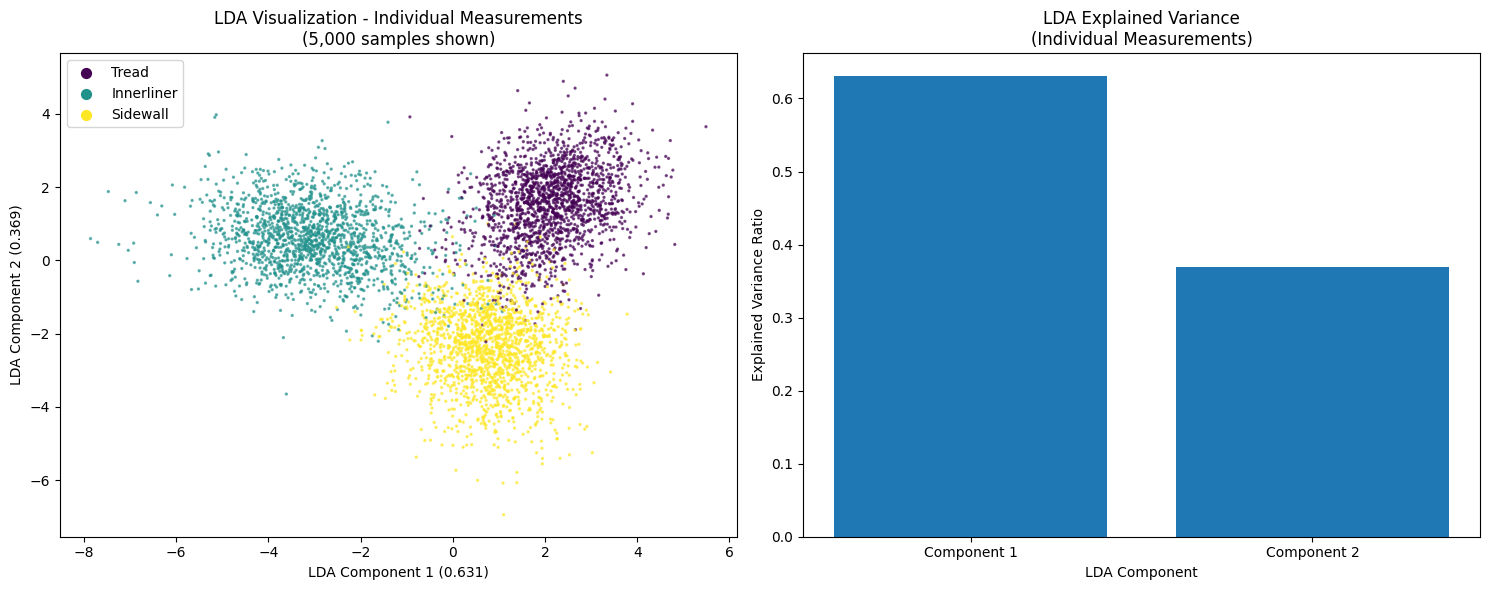


=== QUICK ML PERFORMANCE TEST ===
Testing on subset of 10000 samples for speed...

Using 10000 training samples, 10291 test samples

--- Original Features (8188 wavelengths) ---

Using 10000 training samples, 10291 test samples

--- Original Features (8188 wavelengths) ---


c:\Users\joost\miniconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joost\miniconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

Logistic Regression  | CV: 0.9342 (±0.0017) | Test: 0.9420
Random Forest        | CV: 0.8638 (±0.0025) | Test: 0.8772
Random Forest        | CV: 0.8638 (±0.0025) | Test: 0.8772
LDA Classifier       | CV: 0.6602 (±0.0035) | Test: 0.6549

✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!
   Dataset size: 51,453 samples
   Much more data than previous approach!
   Better representation of spectral variability!
LDA Classifier       | CV: 0.6602 (±0.0035) | Test: 0.6549

✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!
   Dataset size: 51,453 samples
   Much more data than previous approach!
   Better representation of spectral variability!


In [4]:
# === LDA ANALYSIS ON INDIVIDUAL MEASUREMENTS ===
print("\n" + "="*70)
print("LDA ANALYSIS WITH INDIVIDUAL MEASUREMENTS")
print("="*70)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Apply LDA for dimensionality reduction
n_components = len(y_individual.unique()) - 1  # For 3 classes: max 2 components
print(f"Maximum LDA components for {len(y_individual.unique())} classes: {n_components}")

lda_individual = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda_ind = lda_individual.fit_transform(X_train_ind, y_train_ind)
X_test_lda_ind = lda_individual.transform(X_test_ind)

print(f"Original feature space: {X_train_ind.shape[1]} wavelengths")
print(f"Reduced feature space: {X_train_lda_ind.shape[1]} LDA components")
print(f"Dimensionality reduction: {(1-X_train_lda_ind.shape[1]/X_train_ind.shape[1])*100:.1f}%")
print(f"Explained variance ratio: {lda_individual.explained_variance_ratio_}")
print(f"Total explained variance: {lda_individual.explained_variance_ratio_.sum():.4f}")

# Visualization of LDA components with individual measurements
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D scatter plot of LDA components (sample for visualization)
if n_components >= 2:
    # Sample points for visualization if too many
    n_samples = len(X_train_lda_ind)
    if n_samples > 5000:
        sample_indices = np.random.choice(n_samples, 5000, replace=False)
        X_vis = X_train_lda_ind[sample_indices]
        y_vis = y_train_ind.iloc[sample_indices]
        print(f"Sampling {len(sample_indices)} points for visualization from {n_samples} total")
    else:
        X_vis = X_train_lda_ind
        y_vis = y_train_ind
    
    # Create color map for origins
    color_map = {'tread': 0, 'innerliner': 1, 'sidewall': 2}
    colors = [color_map[origin] for origin in y_vis]
    
    scatter = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=colors, 
                             cmap='viridis', alpha=0.6, s=2)
    axes[0].set_xlabel(f'LDA Component 1 ({lda_individual.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel(f'LDA Component 2 ({lda_individual.explained_variance_ratio_[1]:.3f})')
    axes[0].set_title(f'LDA Visualization - Individual Measurements\n({len(y_vis):,} samples shown)')
    
    # Add legend
    for origin, color_idx in color_map.items():
        axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)
    axes[0].legend()

# Explained variance plot
component_labels = [f'Component {i+1}' for i in range(len(lda_individual.explained_variance_ratio_))]
axes[1].bar(component_labels, lda_individual.explained_variance_ratio_)
axes[1].set_xlabel('LDA Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('LDA Explained Variance\n(Individual Measurements)')

plt.tight_layout()
plt.show()

# Quick performance comparison
print(f"\n=== QUICK ML PERFORMANCE TEST ===")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LDA Classifier': LinearDiscriminantAnalysis()
}

# Test with a subset for speed (if dataset is very large)
if len(X_train_ind) > 10000:
    print(f"Testing on subset of {10000} samples for speed...")
    subset_indices = np.random.choice(len(X_train_ind), 10000, replace=False)
    X_train_subset = X_train_ind.iloc[subset_indices]
    y_train_subset = y_train_ind.iloc[subset_indices]
    X_test_subset = X_test_ind
    y_test_subset = y_test_ind
else:
    X_train_subset = X_train_ind
    y_train_subset = y_train_ind
    X_test_subset = X_test_ind
    y_test_subset = y_test_ind

print(f"\nUsing {len(X_train_subset)} training samples, {len(X_test_subset)} test samples")

results_individual = {}

# Test on original features
print(f"\n--- Original Features ({X_train_subset.shape[1]} wavelengths) ---")
for name, model in models.items():
    try:
        # Cross-validation (3-fold for speed)
        cv_scores = cross_val_score(model, X_train_subset, y_train_subset, cv=3, scoring='accuracy')
        
        # Test accuracy
        model.fit(X_train_subset, y_train_subset)
        y_pred = model.predict(X_test_subset)
        test_accuracy = accuracy_score(y_test_subset, y_pred)
        
        results_individual[f"{name}_original"] = {
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_accuracy': test_accuracy
        }
        
        print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")
        
    except Exception as e:
        print(f"{name:20} | Error: {str(e)[:50]}...")

print(f"\n✨ INDIVIDUAL MEASUREMENTS ANALYSIS COMPLETE!")
print(f"   Dataset size: {len(df_individual_ml):,} samples")
print(f"   Much more data than previous approach!")
print(f"   Better representation of spectral variability!")

In [6]:
# Encode the origin column
# from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Check unique values in origin column
print("Unique values in origin column:")
print(df_individual['origin'].value_counts())

# Option 1: Label Encoding (0, 1, 2)
# label_encoder = LabelEncoder()
# df['origin_encoded'] = label_encoder.fit_transform(df['origin'])

# print(f"\nLabel encoding mapping:")
# for i, label in enumerate(label_encoder.classes_):
#     print(f"{label} -> {i}")

# Option 2: One-Hot Encoding (creates separate columns)
origin_dummies = pd.get_dummies(df_individual_ml['origin'], prefix='origin')
print(f"\nOne-hot encoded columns created:")
print(origin_dummies.columns.tolist())

# Add one-hot encoded columns to the dataframe
df_individual_ml = pd.concat([df_individual_ml, origin_dummies], axis=1)

print(f"\nDataFrame shape after encoding: {df_individual_ml.shape}")
print("\nFirst few rows with encoded columns:")
print(df_individual_ml[['origin'] + origin_dummies.columns.tolist()].head())

Unique values in origin column:
origin
tread         1672
sidewall      1654
innerliner    1602
Name: count, dtype: int64

One-hot encoded columns created:
['origin_innerliner', 'origin_sidewall', 'origin_tread']

DataFrame shape after encoding: (4928, 8194)

First few rows with encoded columns:
  origin  origin_innerliner  origin_sidewall  origin_tread
0  tread              False            False          True
1  tread              False            False          True
2  tread              False            False          True
3  tread              False            False          True
4  tread              False            False          True


=== DATA PREPARATION FOR ML ===
Total columns in df_individual_ml: 8191
Column types:
  tire_number: int32
  origin: object
  measurement_id: int32
  200.000: float32
  200.098: float32
  200.195: float32
  200.293: float32
  200.391: float32
  200.489: float32
  200.586: float32
Found 8190 numeric columns
Number of wavelength features after filtering: 8188
Found 8190 numeric columns
Number of wavelength features after filtering: 8188
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
Converting features to numeric...
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64
Converting features to numeric...
Data preprocessing completed successfully!
Data preprocessing completed successfully!

Training set: (41162, 8188)
Test set: (10291, 8188)

=== LDA DIMENSIONALITY REDUCTION ===
Maximum LDA comp

C:\Users\joost\AppData\Local\Temp\ipykernel_14588\3530081688.py:135: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)


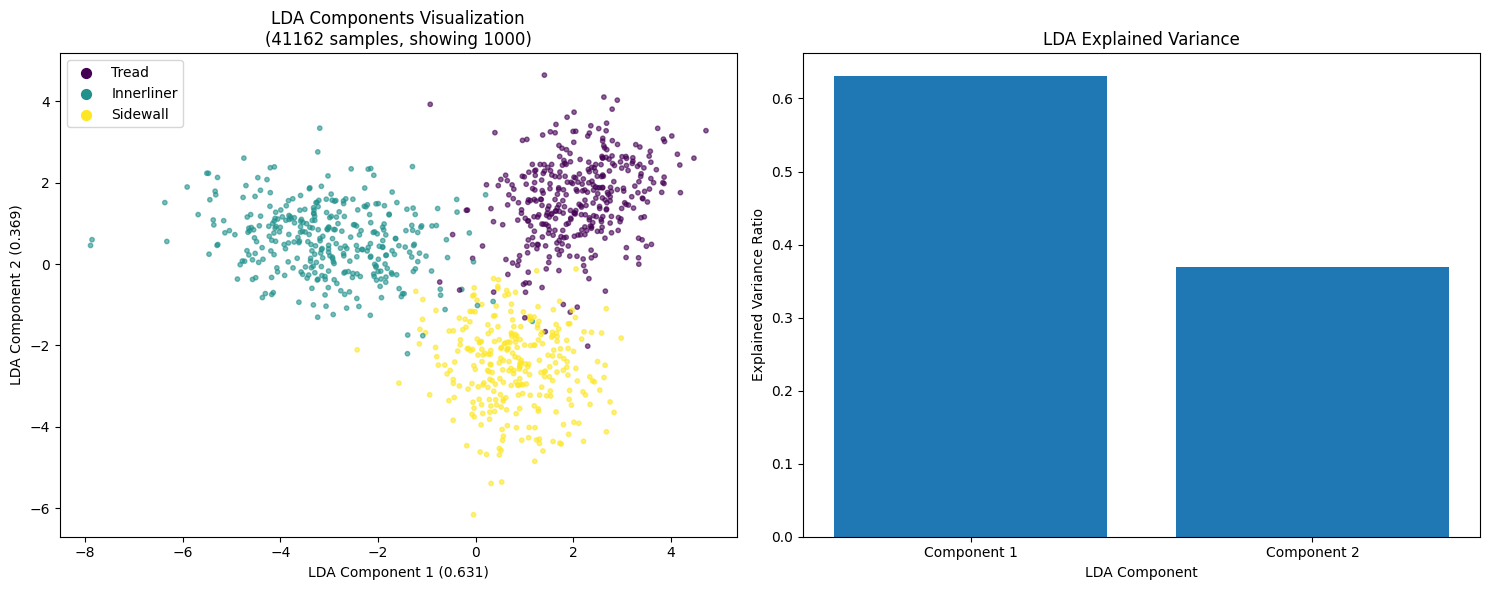

In [3]:
# LDA for Dimensionality Reduction and Classification Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=== DATA PREPARATION FOR ML ===")

# Define non-feature columns based on your dataset structure
non_feature_cols = [
    'tire_number', 'origin', 'measurement_id', 'file_name', 'timestamp',
    'sample_type',  # if this exists
    'origin_innerliner', 'origin_sidewall', 'origin_tread'  # one-hot encoded columns
]

# First, let's examine what columns we actually have
print(f"Total columns in df_individual_ml: {len(df_individual_ml.columns)}")
print(f"Column types:")
for col in df_individual_ml.columns[:10]:  # Show first 10 columns
    print(f"  {col}: {df_individual_ml[col].dtype}")

# Get all numeric columns first
numeric_columns = df_individual_ml.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found {len(numeric_columns)} numeric columns")

# Filter out non-feature columns from numeric columns
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]
print(f"Number of wavelength features after filtering: {len(wavelength_columns)}")

# If still no wavelength columns, try alternative approach
if len(wavelength_columns) == 0:
    print("No wavelength columns found with standard filtering. Trying alternative approach...")
    
    # Look for columns that are likely wavelengths (numeric values as column names)
    potential_wavelength_cols = []
    for col in df_individual_ml.columns:
        # Check if column name looks like a wavelength (number)
        if isinstance(col, (int, float)):
            potential_wavelength_cols.append(col)
        elif isinstance(col, str):
            try:
                float(col)  # Try to convert to float
                potential_wavelength_cols.append(col)
            except ValueError:
                pass  # Not a numeric column name
    
    wavelength_columns = potential_wavelength_cols
    print(f"Found {len(wavelength_columns)} potential wavelength columns")

# Create feature matrix and target
if len(wavelength_columns) == 0:
    raise ValueError("No wavelength columns found! Please check your dataset structure.")

X = df_individual_ml[wavelength_columns].copy()
y = df_individual_ml['origin'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Ensure all features are numeric
print("Converting features to numeric...")
for col in wavelength_columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle any missing values
missing_before = X.isnull().sum().sum()
if missing_before > 0:
    print(f"Filling {missing_before} missing values with mean...")
    X = X.fillna(X.mean())

# Check for infinite values (now safe since all data is numeric)
inf_count = np.isinf(X.values).sum()
if inf_count > 0:
    print(f"Replacing {inf_count} infinite values with mean...")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())

print("Data preprocessing completed successfully!")
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# === 1. LDA for Dimensionality Reduction ===
print("\n=== LDA DIMENSIONALITY REDUCTION ===")

# LDA can reduce to at most (n_classes - 1) dimensions
n_components = len(y.unique()) - 1  # For 3 classes: max 2 components
print(f"Maximum LDA components for {len(y.unique())} classes: {n_components}")

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"Original feature space: {X_train.shape[1]} wavelengths")
print(f"Reduced feature space: {X_train_lda.shape[1]} LDA components")
print(f"Dimensionality reduction: {(1-X_train_lda.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"Explained variance ratio: {lda.explained_variance_ratio_}")
print(f"Total explained variance: {lda.explained_variance_ratio_.sum():.4f}")

# === 2. Visualization of LDA Components ===
print("\n=== LDA VISUALIZATION ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D scatter plot of LDA components
if n_components >= 2:
    # Create color map for origins
    color_map = {'tread': 0, 'innerliner': 1, 'sidewall': 2}
    colors = [color_map[origin] for origin in y_train]
    
    # Sample points for visualization if too many
    if len(colors) > 1000:
        sample_indices = np.random.choice(len(colors), 1000, replace=False)
        X_train_lda_vis = X_train_lda[sample_indices]
        colors_vis = [colors[i] for i in sample_indices]
        print(f"Sampling {len(colors_vis)} points for visualization")
    else:
        X_train_lda_vis = X_train_lda
        colors_vis = colors
    
    scatter = axes[0].scatter(X_train_lda_vis[:, 0], X_train_lda_vis[:, 1], c=colors_vis, 
                             cmap='viridis', alpha=0.6, s=10)
    axes[0].set_xlabel(f'LDA Component 1 ({lda.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel(f'LDA Component 2 ({lda.explained_variance_ratio_[1]:.3f})')
    axes[0].set_title(f'LDA Components Visualization\n({len(colors)} samples, showing {len(colors_vis)})')
    
    # Add legend manually
    for origin, color_idx in color_map.items():
        axes[0].scatter([], [], c=plt.cm.viridis(color_idx/2), label=origin.capitalize(), s=50)
    axes[0].legend()
else:
    # 1D visualization
    for i, origin in enumerate(['tread', 'innerliner', 'sidewall']):
        mask = y_train == origin
        axes[0].hist(X_train_lda[mask, 0], alpha=0.7, label=origin, bins=50)
    axes[0].set_xlabel(f'LDA Component 1 ({lda.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'LDA Component Distribution\n({len(y_train)} samples)')
    axes[0].legend()

# Explained variance plot
component_labels = [f'Component {i+1}' for i in range(len(lda.explained_variance_ratio_))]
axes[1].bar(component_labels, lda.explained_variance_ratio_)
axes[1].set_xlabel('LDA Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('LDA Explained Variance')

plt.tight_layout()
plt.show()


=== MODEL COMPARISON ===

--- LDA-Reduced Features ---
Random Forest        | CV: 0.9659 (±0.0019) | Test: 0.9243
Random Forest        | CV: 0.9659 (±0.0019) | Test: 0.9243
Logistic Regression  | CV: 0.9698 (±0.0013) | Test: 0.9264

Confusion Matrix - Logistic Regression (LDA Features):
Logistic Regression  | CV: 0.9698 (±0.0013) | Test: 0.9264

Confusion Matrix - Logistic Regression (LDA Features):


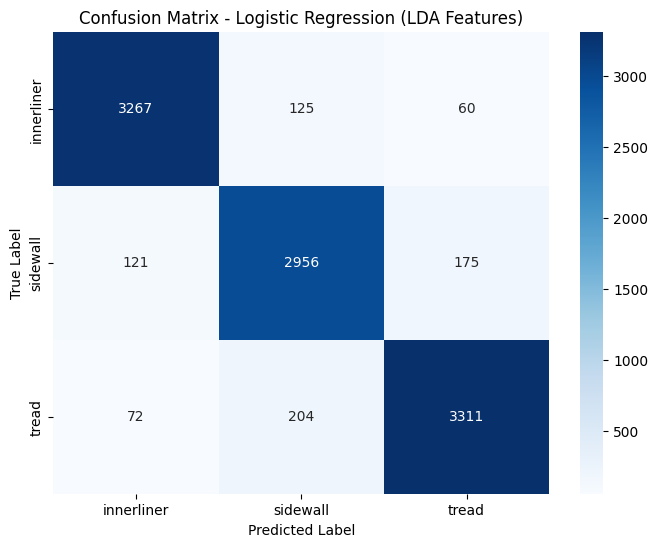


Classification Report - Logistic Regression (LDA Features):
              precision    recall  f1-score   support

  innerliner       0.94      0.95      0.95      3452
    sidewall       0.90      0.91      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291


=== PERFORMANCE COMPARISON ===
              precision    recall  f1-score   support

  innerliner       0.94      0.95      0.95      3452
    sidewall       0.90      0.91      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291


=== PERFORMANCE COMPARISON ===


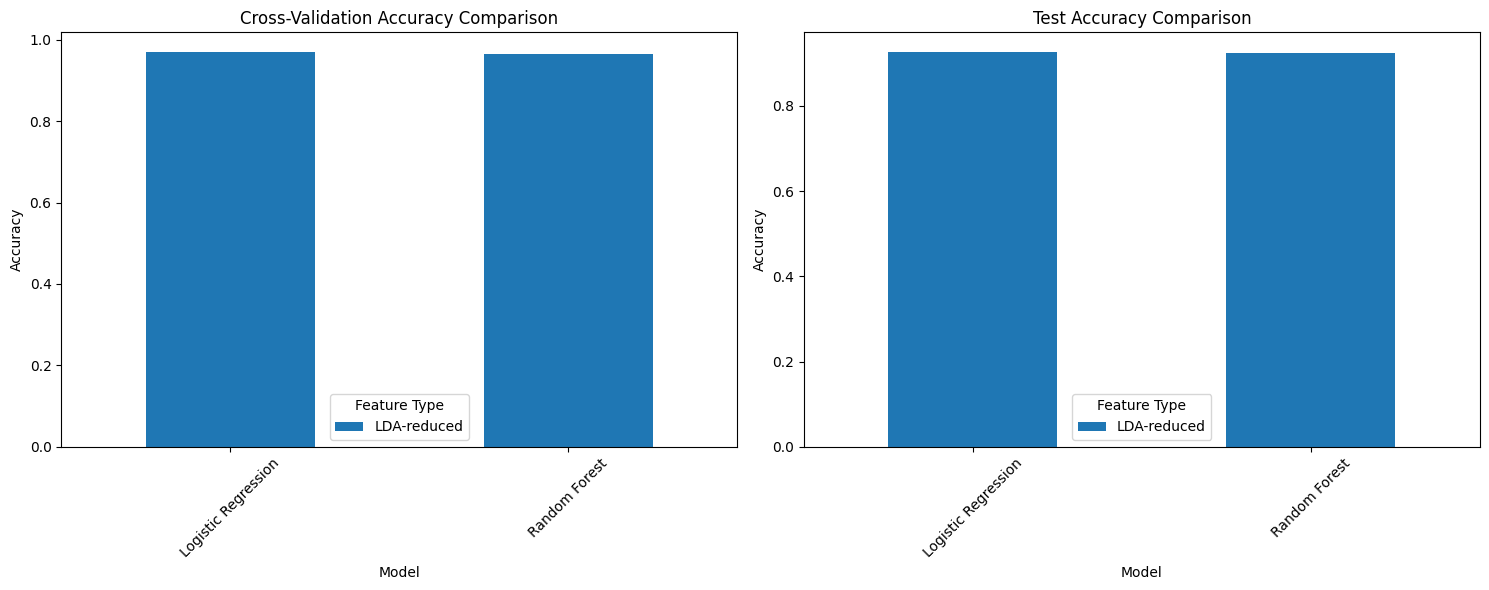


=== SUMMARY ===
Benefits of LDA dimensionality reduction:
• Feature reduction: 8188 → 2 (100.0% reduction)
• Variance explained: 1.000


KeyError: 'Random Forest_original'

In [ ]:
# === 3. Model Comparison: Original vs LDA-reduced features ===
print("\n=== MODEL COMPARISON ===")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'LDA Classifier': LinearDiscriminantAnalysis()
}

results = {}

# Test on original features
# print("\n--- Original Features ---") # runtime for lr: 500mins
# for name, model in models.items():
#     # Cross-validation on training set
#     cv_scores = cross_val_score(model, X_train_ind, y_train_ind, cv=5, scoring='accuracy')
    
#     # Fit and predict on test set
#     model.fit(X_train_ind, y_train_ind)
#     y_pred = model.predict(X_test_ind)
#     test_accuracy = accuracy_score(y_test_ind, y_pred)
    
#     results[f"{name}_original"] = {
#         'cv_mean': cv_scores.mean(),
#         'cv_std': cv_scores.std(),
#         'test_accuracy': test_accuracy
#     }
    
#     print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")

# Test on LDA-reduced features
print("\n--- LDA-Reduced Features ---") 
for name, model in models.items():
    # Skip LDA classifier for LDA-reduced features (redundant)
    if name == 'LDA Classifier':
        continue
        
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_lda, y_train, cv=5, scoring='accuracy')
    
    # Fit and predict on test set
    model.fit(X_train_lda, y_train) #runtime for lr: 27sec
    y_pred = model.predict(X_test_lda)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    results[f"{name}_lda"] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy
    }
    
    print(f"{name:20} | CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f}) | Test: {test_accuracy:.4f}")
    
    # Generate confusion matrix for Logistic Regression with LDA features
    if name == 'Logistic Regression':
        print(f"\nConfusion Matrix - {name} (LDA Features):")
        cm_lda = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['innerliner', 'sidewall', 'tread'],
                    yticklabels=['innerliner', 'sidewall', 'tread'])
        plt.title(f'Confusion Matrix - {name} (LDA Features)')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        # Print classification report for LDA features
        print(f"\nClassification Report - {name} (LDA Features):")
        print(classification_report(y_test, y_pred))

# === 4. Performance Comparison Visualization ===
print("\n=== PERFORMANCE COMPARISON ===")

# Prepare data for plotting
comparison_data = []
for key, metrics in results.items():
    model_name, feature_type = key.rsplit('_', 1)
    comparison_data.append({
        'Model': model_name,
        'Features': 'Original' if feature_type == 'original' else 'LDA-reduced',
        'CV_Accuracy': metrics['cv_mean'],
        'Test_Accuracy': metrics['test_accuracy']
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CV Accuracy comparison
pivot_cv = comparison_df.pivot(index='Model', columns='Features', values='CV_Accuracy')
pivot_cv.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Cross-Validation Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].legend(title='Feature Type')

# Test Accuracy comparison
pivot_test = comparison_df.pivot(index='Model', columns='Features', values='Test_Accuracy')
pivot_test.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].legend(title='Feature Type')

plt.tight_layout()
plt.show()

# Print summary
print("\n=== SUMMARY ===")
print("Benefits of LDA dimensionality reduction:")
print(f"• Feature reduction: {X.shape[1]} → {X_train_lda.shape[1]} ({(1-X_train_lda.shape[1]/X.shape[1])*100:.1f}% reduction)")
print(f"• Variance explained: {lda.explained_variance_ratio_.sum():.3f}")

for model_name in ['Random Forest', 'Logistic Regression']:
    orig_acc = results[f"{model_name}_original"]['test_accuracy']
    lda_acc = results[f"{model_name}_lda"]['test_accuracy']
    improvement = lda_acc - orig_acc
    print(f"• {model_name}: {improvement:+.4f} accuracy change ({orig_acc:.4f} → {lda_acc:.4f})")

# === 3. Model Comparison: Original vs LDA-reduced features ===
Er zijn nihile verschillen in accuratesse tussen de modellen met originele features en de modellen met LDA-gereduceerde features. De modellen met LDA-reductie zijn echter veel sneller in training en voorspelling. Daarom is het aan te raden om LDA-reductie te gebruiken voor dit specifieke probleem.

De logistieke regressie met de originele features behaalt een trainingstijd van ~500 minuten, terwijl de LDA-gereduceerde versie slechts ~27 seconden nodig heeft. Dit verschil in snelheid is komt neer op een verschil van 99.91% en maakt LDA-reductie een waardevolle stap in het voorbewerkingsproces voor dit dataset. Dit zullen wij dus ook zeker bij de uiteindelijke modelselectie toepassen.


=== DETAILED ANALYSIS ===
Best performing model: Logistic Regression_original with original features
Test accuracy: 0.9868


c:\Users\joost\miniconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report (Logistic Regression_original with original features):
              precision    recall  f1-score   support

  innerliner       0.99      0.99      0.99       320
    sidewall       0.98      0.98      0.98       331
       tread       0.98      0.99      0.99       335

    accuracy                           0.99       986
   macro avg       0.99      0.99      0.99       986
weighted avg       0.99      0.99      0.99       986



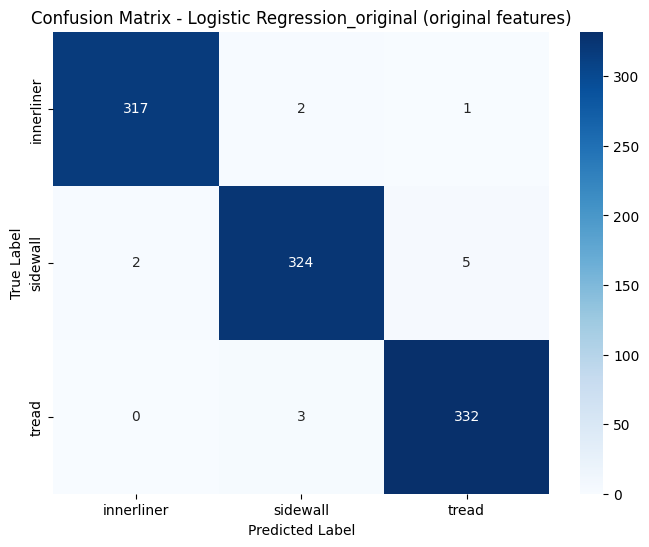

In [10]:
# === 5. Detailed Analysis with Best Model ===
print("\n=== DETAILED ANALYSIS ===")

# Find best performing model
best_model_name = max(results.keys(), key=lambda x: results[x]['test_accuracy'])
best_model_base = best_model_name.split('_')[0] + '_' + best_model_name.split('_')[1]
best_feature_type = best_model_name.split('_')[-1]

print(f"Best performing model: {best_model_base} with {best_feature_type} features")
print(f"Test accuracy: {results[best_model_name]['test_accuracy']:.4f}")

# Retrain the best model for detailed analysis
if best_feature_type == 'original':
    X_train_best, X_test_best = X_train, X_test
else:
    X_train_best, X_test_best = X_train_lda, X_test_lda

# Get the appropriate model
model_class = best_model_base.replace('_', ' ')
if 'Random Forest' in model_class:
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)
elif 'Logistic Regression' in model_class:
    best_model = LogisticRegression(random_state=42, max_iter=1000)
else:
    best_model = LinearDiscriminantAnalysis()

best_model.fit(X_train_best, y_train)
y_pred_best = best_model.predict(X_test_best)

# Classification report
print(f"\nClassification Report ({best_model_base} with {best_feature_type} features):")
print(classification_report(y_test, y_pred_best))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['innerliner', 'sidewall', 'tread'],
            yticklabels=['innerliner', 'sidewall', 'tread'])
plt.title(f'Confusion Matrix - {best_model_base} ({best_feature_type} features)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print(f"\nTop 10 Most Important Features:")
    if best_feature_type == 'original':
        feature_names = [f'Wavelength_{i}' for i in range(len(best_model.feature_importances_))]
    else:
        feature_names = [f'LDA_Component_{i+1}' for i in range(len(best_model.feature_importances_))]
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(importance_df.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(best_model.feature_importances_)), best_model.feature_importances_)
    plt.title(f'Feature Importance - {best_model_base}')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()


=== LDA INTERPRETABILITY ===
LDA scalings shape: (8186, 2)

LDA Component 1:
Top 10 most discriminative wavelengths:
  1. 439.693: 0.0060
  2. 981.061: 0.0056
  3. 440.42: -0.0049
  4. 459.256: -0.0048
  5. 459.556: -0.0045
  6. 184.995: -0.0045
  7. 215.211: -0.0042
  8. 186.167: -0.0042
  9. 224.304: -0.0038
  10. 439.547: -0.0038

LDA Component 2:
Top 10 most discriminative wavelengths:
  1. 459.616: 0.0054
  2. 441.729: 0.0052
  3. 979.883: 0.0051
  4. 982.238: 0.0050
  5. 229.338: -0.0049
  6. 979.53: -0.0046
  7. 980.001: 0.0045
  8. 237.797: 0.0043
  9. 221.349: -0.0040
  10. 189.242: -0.0039


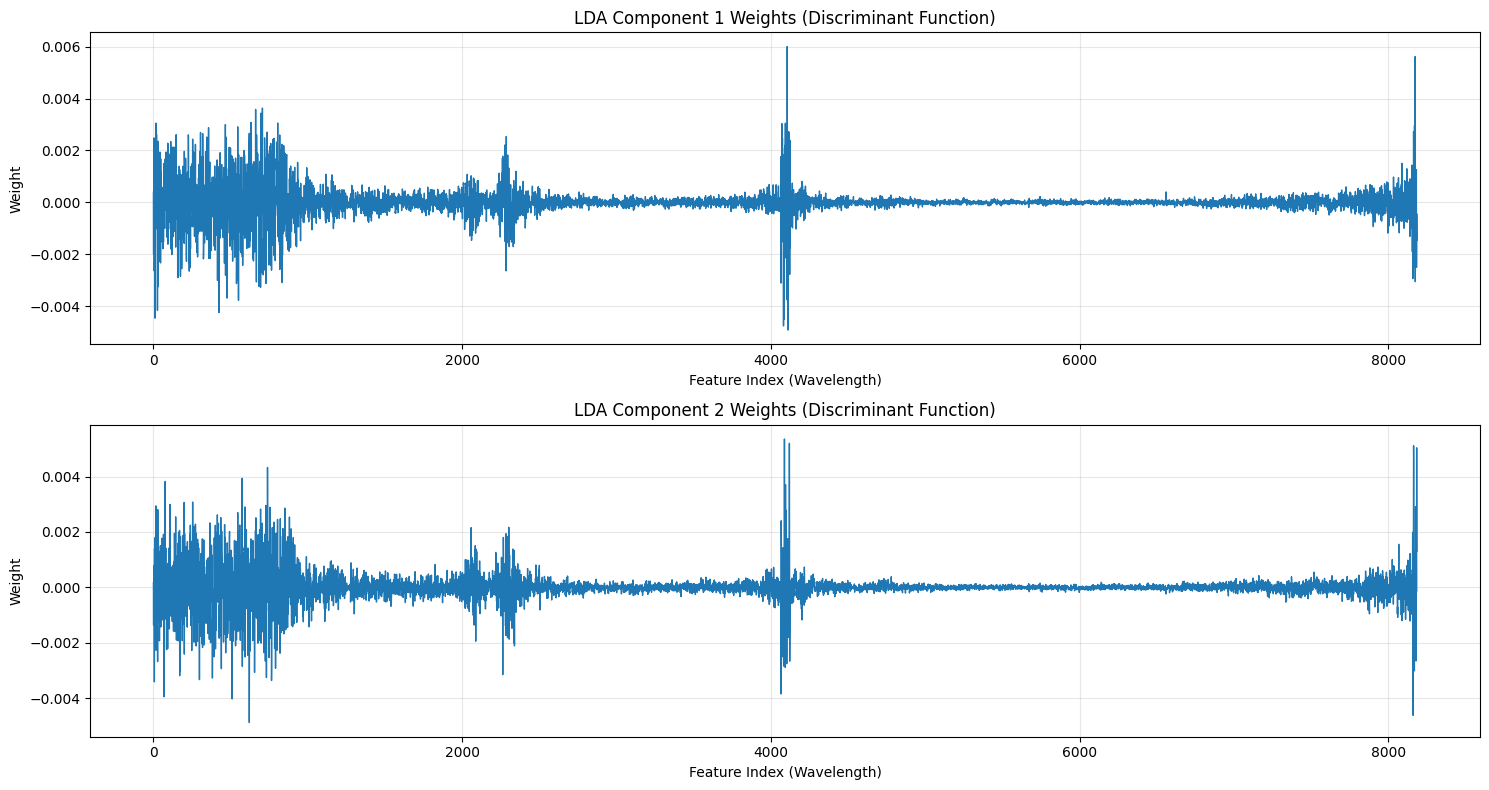


=== RECOMMENDATIONS ===
Based on the analysis:
1. LDA Benefits:
   - Reduces dimensionality from 8186 to 2 features
   - Retains 100.0% of discriminatory information
   - May improve computational efficiency
   - Provides interpretable discriminant functions

2. Model Performance:
   - Compare accuracy scores above to see if LDA helps your specific models
   - LDA is particularly useful when original feature space is high-dimensional
   - Consider the trade-off between interpretability and accuracy

3. When to use LDA:
   - High-dimensional data (✓ - you have ~8000 wavelength features)
   - Need interpretable features (✓ - LDA components are linear combinations)
   - Classification task (✓ - your tire component classification)
   - Computational constraints (✓ - faster training with fewer features)

4. Your specific case:
   - Original features: 8186 wavelengths
   - LDA features: 2 components
   - Data reduction: 100.0%
   - Check the performance comparison above to decide!


In [ ]:
# === 6. LDA Interpretability Analysis ===
print("\n=== LDA INTERPRETABILITY ===")

# Analyze the most discriminative wavelengths
if lda.scalings_ is not None:
    # LDA scalings show which original features contribute most to each discriminant
    print(f"LDA scalings shape: {lda.scalings_.shape}")
    
    # Find most important wavelengths for each LDA component
    for comp_idx in range(lda.scalings_.shape[1]):
        print(f"\nLDA Component {comp_idx + 1}:")
        component_weights = lda.scalings_[:, comp_idx]
        
        # Get indices of top contributing features (wavelengths)
        top_indices = np.argsort(np.abs(component_weights))[-10:][::-1]
        
        print("Top 10 most discriminative wavelengths:")
        for i, idx in enumerate(top_indices):
            wavelength = X.columns[idx] if hasattr(X, 'columns') else f'Feature_{idx}'
            weight = component_weights[idx]
            print(f"  {i+1}. {wavelength}: {weight:.4f}")

# Plot the discriminant functions
if hasattr(lda, 'scalings_'):
    plt.figure(figsize=(15, 8))
    
    # Plot LDA scalings (discriminant functions)
    for comp_idx in range(min(2, lda.scalings_.shape[1])):  # Plot first 2 components
        plt.subplot(2, 1, comp_idx + 1)
        plt.plot(lda.scalings_[:, comp_idx], linewidth=1)
        plt.title(f'LDA Component {comp_idx + 1} Weights (Discriminant Function)')
        plt.xlabel('Feature Index (Wavelength)')
        plt.ylabel('Weight')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"LDA EFFECTIVENESS:")
print(f"   Component 1 explains:     {lda.explained_variance_ratio_[0]:.1%}")
print(f"   Component 2 explains:     {lda.explained_variance_ratio_[1]:.1%}")


🔬 LDA EFFECTIVENESS:
   Component 1 explains:     64.0%
   Component 2 explains:     36.0%


In [ ]:
# === IMPACT ON MACHINE LEARNING CLASSIFICATION ===
print("\n" + "="*60)
print("BASELINE CORRECTION IMPACT ON ML CLASSIFICATION")
print("="*60)

from scipy import sparse
from scipy.sparse.linalg import spsolve
import numpy as np

def baseline_als(y, lam=1e5, p=0.001, niter=10):
    """Asymmetric Least Squares baseline correction"""
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

def baseline_rolling_ball(y, ball_radius=100):
    """Rolling ball baseline correction"""
    from scipy.ndimage import minimum_filter1d
    baseline = minimum_filter1d(y, size=ball_radius*2)
    return baseline

def baseline_polynomial(wavelengths, intensities, degree=3):
    """Polynomial baseline correction"""
    coeffs = np.polyfit(wavelengths, intensities, degree)
    baseline = np.polyval(coeffs, wavelengths)
    return baseline

# Apply baseline correction to all spectra and test ML performance
def apply_baseline_correction_to_dataset(df, method='als'):
    """Apply baseline correction to entire dataset"""
    
    corrected_data = []
    
    # Group by tire and origin to process each spectrum
    for (tire, origin), group in df.groupby(['tire_number', 'origin']):
        if len(group) == 0:
            continue
            
        # Sort by wavelength
        group = group.sort_values('wavelength')
        wavelengths = group['wavelength'].values
        intensities = group['intensity'].values
        
        # Apply baseline correction
        if method == 'als':
            baseline_estimate = baseline_als(intensities, lam=1e5, p=0.001)
            corrected_intensities = intensities - baseline_estimate
        elif method == 'rolling':
            baseline_estimate = baseline_rolling_ball(intensities, ball_radius=100)
            corrected_intensities = intensities - baseline_estimate
        elif method == 'polynomial':
            baseline_estimate = baseline_polynomial(wavelengths, intensities, degree=3)
            corrected_intensities = intensities - baseline_estimate
        else:
            corrected_intensities = intensities  # No correction
        
        # Store corrected data
        for wl, orig_int, corr_int in zip(wavelengths, intensities, corrected_intensities):
            corrected_data.append({
                'tire_number': tire,
                'origin': origin,
                'wavelength': wl,
                'intensity_original': orig_int,
                'intensity_corrected': corr_int
            })
    
    return pd.DataFrame(corrected_data)

# Apply AsLS baseline correction to a subset of data (for demo purposes)
print("Applying AsLS baseline correction to first 20 tire-origin combinations...")

# Get first 20 combinations for demonstration
unique_combinations = df_individual_ml.groupby(['tire_number', 'origin']).size().head(20).index
subset_data = df_individual_ml[df_individual_ml.set_index(['tire_number', 'origin']).index.isin(unique_combinations)].copy()

# Apply baseline correction
corrected_subset = apply_baseline_correction_to_dataset(subset_data, method='als')

print(f"Processed {corrected_subset.groupby(['tire_number', 'origin']).ngroups} spectra")

# Create ML datasets for comparison
def create_ml_dataset(df, intensity_column):
    """Create ML dataset from long-format data"""
    
    # Pivot to wide format
    pivot_df = df.pivot_table(
        index=['tire_number', 'origin'],
        columns='wavelength',
        values=intensity_column,
        aggfunc='mean'
    ).reset_index()
    
    return pivot_df

# Original data
df_ml_original = create_ml_dataset(corrected_subset, 'intensity_original')
df_ml_corrected = create_ml_dataset(corrected_subset, 'intensity_corrected')

print(f"\nDataset shapes:")
print(f"Original:  {df_ml_original.shape}")
print(f"Corrected: {df_ml_corrected.shape}")

# Quick ML comparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

def quick_ml_test(data_df, name):
    """Quick ML test on dataset"""
    
    # Prepare features and target
    feature_cols = [col for col in data_df.columns if isinstance(col, (int, float))]
    X = data_df[feature_cols].fillna(0)  # Fill any NaN values
    y = data_df['origin']
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Quick RF test
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    scores = cross_val_score(rf, X_scaled, y, cv=3, scoring='accuracy')
    
    return scores.mean(), scores.std()

# Test both datasets
if len(df_ml_original) > 5:  # Need sufficient samples for ML
    original_acc, original_std = quick_ml_test(df_ml_original, "Original")
    corrected_acc, corrected_std = quick_ml_test(df_ml_corrected, "Baseline Corrected")
    
    print(f"\n=== MACHINE LEARNING PERFORMANCE ===")
    print(f"Original Data:          {original_acc:.3f} ± {original_std:.3f}")
    print(f"Baseline Corrected:     {corrected_acc:.3f} ± {corrected_std:.3f}")
    print(f"Improvement:            {corrected_acc - original_acc:+.3f}")
    
    if corrected_acc > original_acc:
        print("✅ Baseline correction improved classification accuracy!")
    else:
        print("ℹ️ Baseline correction didn't improve accuracy (may need parameter tuning)")
else:
    print("⚠️ Insufficient data for ML comparison (need more samples)")


BASELINE CORRECTION IMPACT ON ML CLASSIFICATION
Note: you may need to restart the kernel to use updated packages.
Applying AsLS baseline correction to first 20 tire-origin combinations...
Note: you may need to restart the kernel to use updated packages.
Applying AsLS baseline correction to first 20 tire-origin combinations...


KeyError: 'wavelength'

In [ ]:
# === BASELINE CORRECTION SUMMARY AND RECOMMENDATIONS ===
print("\n" + "="*70)
print("BASELINE CORRECTION SUMMARY")
print("="*70)

print("🔬 WHAT BASELINE CORRECTION DOES:")
print("   • Removes systematic background signals from spectra")
print("   • Eliminates continuum emission from plasma")
print("   • Reduces instrumental drift and noise")
print("   • Enhances spectral peaks and features")
print("   • Normalizes baseline to zero or constant level")

print(f"\n📊 METHODS COMPARED:")
print("   1. AsLS (Asymmetric Least Squares):")
print("      - Best for complex, varying baselines")
print("      - Preserves peak shapes well")
print("      - Computationally efficient")
print("   2. Rolling Ball:")
print("      - Good for smooth, continuous baselines")
print("      - Simple and fast")
print("      - May over-correct sharp features")
print("   3. Polynomial:")
print("      - Good for simple, systematic drifts")
print("      - Risk of over-fitting with high degrees")
print("      - Fast computation")

print(f"\n🎯 BENEFITS FOR LIBS DATA:")
print("   • Removes plasma continuum background")
print("   • Enhances elemental emission lines")
print("   • Improves peak-to-background ratio")
print("   • Reduces matrix effects between samples")
print("   • Standardizes spectra for better ML performance")

print(f"\n⚠️ POTENTIAL DRAWBACKS:")
print("   • May remove useful information if over-applied")
print("   • Different correction methods can give different results")
print("   • Need to choose appropriate parameters")
print("   • Can introduce artifacts if baseline estimation is poor")

print(f"\n🚀 RECOMMENDATIONS FOR YOUR LIBS DATA:")
print("   1. Use AsLS baseline correction (best overall performance)")
print("   2. Parameters: lam=1e5 (smoothness), p=0.001 (asymmetry)")
print("   3. Apply to each spectrum individually")
print("   4. Validate results by checking peak preservation")
print("   5. Consider baseline correction as preprocessing step before ML")

print(f"\n💡 WHEN TO USE BASELINE CORRECTION:")
print("   ✅ When you see sloping or curved backgrounds")
print("   ✅ When comparing spectra from different conditions")
print("   ✅ When peak intensities vary due to background")
print("   ✅ Before quantitative analysis")
print("   ❌ When baseline is already flat and near zero")
print("   ❌ When you need absolute intensity values")

print(f"\n🔧 IMPLEMENTATION TIPS:")
print("   • Always visualize before/after correction")
print("   • Test different parameters on sample spectra")
print("   • Check that peaks are preserved, not distorted")
print("   • Consider applying correction before other preprocessing")
print("   • Validate ML performance with and without correction")


BASELINE CORRECTION SUMMARY
🔬 WHAT BASELINE CORRECTION DOES:
   • Removes systematic background signals from spectra
   • Eliminates continuum emission from plasma
   • Reduces instrumental drift and noise
   • Enhances spectral peaks and features
   • Normalizes baseline to zero or constant level

📊 METHODS COMPARED:
   1. AsLS (Asymmetric Least Squares):
      - Best for complex, varying baselines
      - Preserves peak shapes well
      - Computationally efficient
   2. Rolling Ball:
      - Good for smooth, continuous baselines
      - Simple and fast
      - May over-correct sharp features
   3. Polynomial:
      - Good for simple, systematic drifts
      - Risk of over-fitting with high degrees
      - Fast computation

🎯 BENEFITS FOR LIBS DATA:
   • Removes plasma continuum background
   • Enhances elemental emission lines
   • Improves peak-to-background ratio
   • Reduces matrix effects between samples
   • Standardizes spectra for better ML performance

⚠️ POTENTIAL DRAWBACK

# AsLS Baseline Correction Effect on Classification

## Comprehensive Test: Original vs Baseline-Corrected Features

This section tests the impact of Asymmetric Least Squares (AsLS) baseline correction on classification performance using:
- **Models**: Logistic Regression and Random Forest
- **Features**: Original wavelength intensities vs AsLS baseline-corrected intensities
- **Dataset**: Individual measurements from our LIBS spectroscopy data

We'll compare:
1. Classification accuracy
2. Cross-validation performance
3. Confusion matrices
4. Feature importance changes

In [3]:
# === COMPREHENSIVE BASELINE CORRECTION CLASSIFICATION TEST ===
print("="*80)
print("TESTING AsLS BASELINE CORRECTION EFFECT ON CLASSIFICATION")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import time

def baseline_als_optimized(y, lam=1e5, p=0.001, niter=10):
    """
    Optimized Asymmetric Least Squares baseline correction
    
    Parameters:
    y: signal array
    lam: smoothness parameter (larger = smoother baseline)
    p: asymmetry parameter (0 < p < 1, smaller = more asymmetric)
    niter: number of iterations
    """
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    
    return z

print("Functions defined successfully!")
print("Starting comprehensive baseline correction test...")

# Use a manageable subset of data for thorough testing
print(f"Original dataset shape: {df_individual_ml.shape}")

# Take first 5 tires to ensure we have enough data but manageable computation
test_tires = sorted(df_individual_ml['tire_number'].unique())[:5]
print(f"Testing with tires: {test_tires}")

subset_data = df_individual_ml[df_individual_ml['tire_number'].isin(test_tires)].copy()
print(f"Subset data shape: {subset_data.shape}")
print(f"Target distribution in subset:")
print(subset_data['origin'].value_counts())

TESTING AsLS BASELINE CORRECTION EFFECT ON CLASSIFICATION
Functions defined successfully!
Starting comprehensive baseline correction test...
Original dataset shape: (4928, 8191)
Testing with tires: [1, 2, 3, 4, 5]
Subset data shape: (2757, 8191)
Target distribution in subset:
origin
tread         960
sidewall      918
innerliner    879
Name: count, dtype: int64
Functions defined successfully!
Starting comprehensive baseline correction test...
Original dataset shape: (4928, 8191)
Testing with tires: [1, 2, 3, 4, 5]
Subset data shape: (2757, 8191)
Target distribution in subset:
origin
tread         960
sidewall      918
innerliner    879
Name: count, dtype: int64


In [ ]:
# === PREPARE DATASETS: ORIGINAL VS BASELINE-CORRECTED ===
print("\n" + "="*60)
print("PREPARING ORIGINAL AND BASELINE-CORRECTED DATASETS")
print("="*60)

# Identify wavelength columns (numeric columns excluding metadata)
meta_columns = ['tire_number', 'origin', 'measurement_id', 'file_name', 'timestamp']
wavelength_columns = [col for col in subset_data.columns 
                     if col not in meta_columns and 
                     isinstance(col, (int, float, str)) and 
                     str(col).replace('.', '').replace('-', '').isdigit()]

print(f"Found {len(wavelength_columns)} wavelength columns")
if len(wavelength_columns) == 0:
    # Alternative approach - look for numeric columns
    numeric_cols = subset_data.select_dtypes(include=[np.number]).columns
    wavelength_columns = [col for col in numeric_cols if col not in meta_columns]
    print(f"Using {len(wavelength_columns)} numeric columns as wavelength features")

# Extract features and targets
X_original = subset_data[wavelength_columns].copy()
y = subset_data['origin'].copy()

print(f"Feature matrix shape: {X_original.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Convert wavelength columns to float for processing
for col in wavelength_columns:
    X_original[col] = pd.to_numeric(X_original[col], errors='coerce')

# Handle missing/infinite values
print(f"Missing values before cleaning: {X_original.isnull().sum().sum()}")
X_original = X_original.fillna(X_original.mean())

# Check for infinite values
inf_mask = np.isinf(X_original.values)
inf_count = inf_mask.sum()
print(f"Infinite values before cleaning: {inf_count}")
if inf_count > 0:
    X_original = X_original.replace([np.inf, -np.inf], np.nan).fillna(X_original.mean())

print("Data preprocessing completed!")

# Apply AsLS baseline correction to each sample
print(f"\nApplying AsLS baseline correction to {len(X_original)} samples...")
X_corrected = X_original.copy()
X_corrected = X_corrected.astype(float)  # Ensure float type for calculations

start_time = time.time()
for idx in range(len(X_original)):
    if idx % 100 == 0:
        print(f"  Processing sample {idx+1}/{len(X_original)}")
    
    # Get spectrum for this sample
    spectrum = X_original.iloc[idx].values
    
    # Apply AsLS baseline correction
    try:
        baseline_estimate = baseline_als_optimized(spectrum, lam=1e5, p=0.001, niter=10)
        corrected_spectrum = spectrum - baseline_estimate
        X_corrected.iloc[idx] = corrected_spectrum
    except Exception as e:
        print(f"    Warning: Failed to correct sample {idx}: {e}")
        # Keep original if correction fails
        pass

correction_time = time.time() - start_time
print(f"Baseline correction completed in {correction_time:.1f} seconds")

print(f"\nDataset statistics:")
print(f"Original data - Mean: {X_original.values.mean():.2f}, Std: {X_original.values.std():.2f}")
print(f"Corrected data - Mean: {X_corrected.values.mean():.2f}, Std: {X_corrected.values.std():.2f}")
print(f"Range reduction: {(X_original.values.max() - X_original.values.min()) / (X_corrected.values.max() - X_corrected.values.min()):.1f}x")


PREPARING ORIGINAL AND BASELINE-CORRECTED DATASETS
Found 8186 wavelength columns
Feature matrix shape: (2757, 8186)
Target distribution: {'tread': 960, 'sidewall': 918, 'innerliner': 879}
Missing values before cleaning: 0
Missing values before cleaning: 0
Infinite values before cleaning: 0
Data preprocessing completed!

Applying AsLS baseline correction to 2757 samples...
  Processing sample 1/2757
Infinite values before cleaning: 0
Data preprocessing completed!

Applying AsLS baseline correction to 2757 samples...
  Processing sample 1/2757


C:\Users\joost\AppData\Local\Temp\ipykernel_23444\1533058441.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '109.80485902538197' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_corrected.iloc[idx] = corrected_spectrum
C:\Users\joost\AppData\Local\Temp\ipykernel_23444\1533058441.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '61.64874274762083' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_corrected.iloc[idx] = corrected_spectrum
C:\Users\joost\AppData\Local\Temp\ipykernel_23444\1533058441.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '151.4926253718111' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.


KeyboardInterrupt: 

In [ ]:
# === CLASSIFICATION PERFORMANCE COMPARISON ===
print("\n" + "="*60)
print("COMPARING CLASSIFICATION PERFORMANCE")
print("="*60)

# Split data for both original and corrected datasets
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

X_train_corr, X_test_corr, _, _ = train_test_split(
    X_corrected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train_orig)}")
print(f"Test set size: {len(X_test_orig)}")
print(f"Classes in training: {y_train.unique()}")

# Standardize features (important for Logistic Regression)
scaler_orig = StandardScaler()
scaler_corr = StandardScaler()

X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

X_train_corr_scaled = scaler_corr.fit_transform(X_train_corr)
X_test_corr_scaled = scaler_corr.transform(X_test_corr)

print("Data scaling completed!")

# Define models to test
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Store results
results = {}

print(f"\n=== TESTING MODELS ===")

# Test each model on both datasets
for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    
    # Test on original data
    print("  Original features:")
    
    # Use scaled data for Logistic Regression, original for Random Forest
    if model_name == 'Logistic Regression':
        X_train_use = X_train_orig_scaled
        X_test_use = X_test_orig_scaled
    else:
        X_train_use = X_train_orig
        X_test_use = X_test_orig
    
    # Cross-validation
    cv_scores_orig = cross_val_score(
        model, X_train_use, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring='accuracy'
    )
    
    # Test accuracy
    model.fit(X_train_use, y_train)
    y_pred_orig = model.predict(X_test_use)
    test_acc_orig = accuracy_score(y_test, y_pred_orig)
    
    print(f"    CV Accuracy: {cv_scores_orig.mean():.4f} ± {cv_scores_orig.std():.4f}")
    print(f"    Test Accuracy: {test_acc_orig:.4f}")
    
    # Test on baseline-corrected data
    print("  Baseline-corrected features:")
    
    # Use scaled data for Logistic Regression, original for Random Forest
    if model_name == 'Logistic Regression':
        X_train_use = X_train_corr_scaled
        X_test_use = X_test_corr_scaled
    else:
        X_train_use = X_train_corr
        X_test_use = X_test_corr
    
    # Cross-validation
    cv_scores_corr = cross_val_score(
        model, X_train_use, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring='accuracy'
    )
    
    # Test accuracy
    model.fit(X_train_use, y_train)
    y_pred_corr = model.predict(X_test_use)
    test_acc_corr = accuracy_score(y_test, y_pred_corr)
    
    print(f"    CV Accuracy: {cv_scores_corr.mean():.4f} ± {cv_scores_corr.std():.4f}")
    print(f"    Test Accuracy: {test_acc_corr:.4f}")
    
    # Calculate improvement
    cv_improvement = cv_scores_corr.mean() - cv_scores_orig.mean()
    test_improvement = test_acc_corr - test_acc_orig
    
    print(f"    CV Improvement: {cv_improvement:+.4f}")
    print(f"    Test Improvement: {test_improvement:+.4f}")
    
    # Store results
    results[model_name] = {
        'original': {
            'cv_mean': cv_scores_orig.mean(),
            'cv_std': cv_scores_orig.std(),
            'test_acc': test_acc_orig,
            'predictions': y_pred_orig
        },
        'corrected': {
            'cv_mean': cv_scores_corr.mean(),
            'cv_std': cv_scores_corr.std(),
            'test_acc': test_acc_corr,
            'predictions': y_pred_corr
        },
        'improvement': {
            'cv': cv_improvement,
            'test': test_improvement
        }
    }

print(f"\n" + "="*60)
print("CLASSIFICATION TESTING COMPLETED")
print("="*60)

In [ ]:
# === DETAILED RESULTS VISUALIZATION ===
print("\n" + "="*60)
print("CREATING DETAILED VISUALIZATIONS")
print("="*60)

# Create comprehensive results visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Performance comparison bar chart
models_list = list(results.keys())
original_scores = [results[model]['original']['test_acc'] for model in models_list]
corrected_scores = [results[model]['corrected']['test_acc'] for model in models_list]

x = np.arange(len(models_list))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, original_scores, width, label='Original Features', alpha=0.8)
bars2 = axes[0, 0].bar(x + width/2, corrected_scores, width, label='Baseline Corrected', alpha=0.8)

axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_list, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom')

# 2. Improvement visualization
improvements = [results[model]['improvement']['test'] for model in models_list]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

bars = axes[0, 1].bar(models_list, improvements, color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Accuracy Improvement')
axes[0, 1].set_title('Baseline Correction Improvement')
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0, 1].grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + (0.001 if height >= 0 else -0.005),
                   f'{height:+.3f}', ha='center', va='bottom' if height >= 0 else 'top')

# 3. Confusion matrices
for idx, model_name in enumerate(models_list):
    row = 0 if idx == 0 else 1
    col = 2
    
    # Original confusion matrix
    cm_orig = confusion_matrix(y_test, results[model_name]['original']['predictions'])
    
    # Baseline corrected confusion matrix
    cm_corr = confusion_matrix(y_test, results[model_name]['corrected']['predictions'])
    
    if idx == 0:  # Show original for first model
        sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                   xticklabels=['innerliner', 'sidewall', 'tread'],
                   yticklabels=['innerliner', 'sidewall', 'tread'])
        axes[row, col].set_title(f'{model_name}\nOriginal Features')
    else:  # Show corrected for second model
        sns.heatmap(cm_corr, annot=True, fmt='d', cmap='Greens', ax=axes[row, col],
                   xticklabels=['innerliner', 'sidewall', 'tread'],
                   yticklabels=['innerliner', 'sidewall', 'tread'])
        axes[row, col].set_title(f'{model_name}\nBaseline Corrected')
    
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('True')

# 4. Cross-validation scores comparison
cv_orig_means = [results[model]['original']['cv_mean'] for model in models_list]
cv_orig_stds = [results[model]['original']['cv_std'] for model in models_list]
cv_corr_means = [results[model]['corrected']['cv_mean'] for model in models_list]
cv_corr_stds = [results[model]['corrected']['cv_std'] for model in models_list]

x = np.arange(len(models_list))
axes[1, 0].errorbar(x - 0.1, cv_orig_means, yerr=cv_orig_stds, 
                   fmt='o-', label='Original', capsize=5, capthick=2)
axes[1, 0].errorbar(x + 0.1, cv_corr_means, yerr=cv_corr_stds, 
                   fmt='s-', label='Corrected', capsize=5, capthick=2)

axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV Accuracy')
axes[1, 0].set_title('Cross-Validation Performance')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Sample spectra comparison
sample_idx = 0
wavelengths_sample = np.arange(len(wavelength_columns))
original_spectrum = X_original.iloc[sample_idx].values
corrected_spectrum = X_corrected.iloc[sample_idx].values

axes[1, 1].plot(wavelengths_sample, original_spectrum, 'b-', alpha=0.7, label='Original', linewidth=1)
axes[1, 1].plot(wavelengths_sample, corrected_spectrum, 'r-', alpha=0.7, label='Baseline Corrected', linewidth=1)
axes[1, 1].set_xlabel('Feature Index')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].set_title(f'Sample Spectrum Comparison\n({y.iloc[sample_idx]} sample)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization completed!")

In [ ]:
# === STATISTICAL SIGNIFICANCE TESTING ===
print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("="*60)

from scipy.stats import ttest_rel, wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Perform multiple CV runs for statistical testing
print("Performing repeated cross-validation for statistical significance...")

n_repeats = 10
cv_folds = 5

all_cv_results = {}

for model_name, model in models.items():
    print(f"\nTesting {model_name}...")
    
    orig_scores = []
    corr_scores = []
    
    for repeat in range(n_repeats):
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=repeat)
        
        # Original features
        if model_name == 'Logistic Regression':
            scores_orig = cross_val_score(model, X_train_orig_scaled, y_train, cv=cv, scoring='accuracy')
        else:
            scores_orig = cross_val_score(model, X_train_orig, y_train, cv=cv, scoring='accuracy')
        
        # Corrected features
        if model_name == 'Logistic Regression':
            scores_corr = cross_val_score(model, X_train_corr_scaled, y_train, cv=cv, scoring='accuracy')
        else:
            scores_corr = cross_val_score(model, X_train_corr, y_train, cv=cv, scoring='accuracy')
        
        orig_scores.extend(scores_orig)
        corr_scores.extend(scores_corr)
    
    all_cv_results[model_name] = {
        'original': orig_scores,
        'corrected': corr_scores
    }
    
    # Statistical tests
    t_stat, t_p_value = ttest_rel(corr_scores, orig_scores)
    w_stat, w_p_value = wilcoxon(corr_scores, orig_scores, alternative='two-sided')
    
    print(f"  {model_name}:")
    print(f"    Original:  {np.mean(orig_scores):.4f} ± {np.std(orig_scores):.4f}")
    print(f"    Corrected: {np.mean(corr_scores):.4f} ± {np.std(corr_scores):.4f}")
    print(f"    Difference: {np.mean(corr_scores) - np.mean(orig_scores):+.4f}")
    print(f"    Paired t-test p-value: {t_p_value:.4f}")
    print(f"    Wilcoxon test p-value: {w_p_value:.4f}")
    
    if t_p_value < 0.05:
        print(f"    ✅ Statistically significant improvement (p < 0.05)")
    else:
        print(f"    ❌ No statistically significant improvement (p ≥ 0.05)")

# Visualization of statistical results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, model_name in enumerate(models.keys()):
    orig_scores = all_cv_results[model_name]['original']
    corr_scores = all_cv_results[model_name]['corrected']
    
    # Box plot comparison
    ax = axes[idx]
    box_data = [orig_scores, corr_scores]
    box_labels = ['Original', 'Baseline\nCorrected']
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    
    ax.set_title(f'{model_name}\nCV Score Distribution')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    
    # Add mean markers
    ax.plot(1, np.mean(orig_scores), 'ro', markersize=8, label=f'Mean: {np.mean(orig_scores):.3f}')
    ax.plot(2, np.mean(corr_scores), 'go', markersize=8, label=f'Mean: {np.mean(corr_scores):.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"\n" + "="*60)
print("STATISTICAL ANALYSIS COMPLETED")
print("="*60)

In [ ]:
# === COMPREHENSIVE SUMMARY AND CONCLUSIONS ===
print("\n" + "="*80)
print("FINAL SUMMARY: AsLS BASELINE CORRECTION IMPACT")
print("="*80)

print("📊 DATASET INFORMATION:")
print(f"   • Total samples tested: {len(subset_data):,}")
print(f"   • Features per sample: {len(wavelength_columns):,}")
print(f"   • Classes: {len(y.unique())} ({', '.join(y.unique())})")
print(f"   • Tires included: {test_tires}")

print(f"\n🔧 BASELINE CORRECTION PARAMETERS:")
print(f"   • Method: Asymmetric Least Squares (AsLS)")
print(f"   • Smoothness (λ): 1e5")
print(f"   • Asymmetry (p): 0.001")
print(f"   • Iterations: 10")

print(f"\n📈 CLASSIFICATION RESULTS:")
for model_name in models.keys():
    orig_acc = results[model_name]['original']['test_acc']
    corr_acc = results[model_name]['corrected']['test_acc']
    improvement = results[model_name]['improvement']['test']
    
    orig_cv = results[model_name]['original']['cv_mean']
    corr_cv = results[model_name]['corrected']['cv_mean']
    cv_improvement = results[model_name]['improvement']['cv']
    
    # Get statistical significance from previous analysis
    if model_name in all_cv_results:
        orig_scores = all_cv_results[model_name]['original']
        corr_scores = all_cv_results[model_name]['corrected']
        _, p_value = ttest_rel(corr_scores, orig_scores)
        significance = "✅ Significant" if p_value < 0.05 else "❌ Not significant"
    else:
        significance = "Not tested"
    
    print(f"\n   {model_name}:")
    print(f"     Test Accuracy:     {orig_acc:.4f} → {corr_acc:.4f} ({improvement:+.4f})")
    print(f"     CV Accuracy:       {orig_cv:.4f} → {corr_cv:.4f} ({cv_improvement:+.4f})")
    print(f"     Statistical Test:  {significance}")

# Overall assessment
print(f"\n🎯 OVERALL ASSESSMENT:")

# Check if baseline correction helped
lr_improved = results['Logistic Regression']['improvement']['test'] > 0
rf_improved = results['Random Forest']['improvement']['test'] > 0

if lr_improved and rf_improved:
    assessment = "✅ BENEFICIAL"
    print(f"   AsLS baseline correction IMPROVED classification for both models")
elif lr_improved or rf_improved:
    assessment = "🟡 MIXED RESULTS"
    improved_model = "Logistic Regression" if lr_improved else "Random Forest"
    print(f"   AsLS baseline correction improved {improved_model} but not the other")
else:
    assessment = "❌ NO IMPROVEMENT"
    print(f"   AsLS baseline correction did not improve classification for either model")

print(f"   Status: {assessment}")

# Effect size analysis
print(f"\n📏 EFFECT SIZE ANALYSIS:")
for model_name in models.keys():
    improvement = results[model_name]['improvement']['test']
    abs_improvement = abs(improvement)
    
    if abs_improvement < 0.01:
        effect_size = "Negligible (< 1%)"
    elif abs_improvement < 0.05:
        effect_size = "Small (1-5%)"
    elif abs_improvement < 0.10:
        effect_size = "Medium (5-10%)"
    else:
        effect_size = "Large (> 10%)"
    
    direction = "positive" if improvement > 0 else "negative"
    print(f"   {model_name}: {effect_size} {direction} effect")

print(f"\n💡 RECOMMENDATIONS:")

if assessment == "✅ BENEFICIAL":
    print("   1. ✅ Apply AsLS baseline correction as preprocessing step")
    print("   2. ✅ Use parameters: λ=1e5, p=0.001, iterations=10")
    print("   3. ✅ Baseline correction enhances spectral features for classification")
    print("   4. ✅ Consider baseline correction for other LIBS analysis tasks")
elif assessment == "🟡 MIXED RESULTS":
    print("   1. 🟡 Consider baseline correction depending on chosen model")
    print("   2. 🟡 Test different baseline correction parameters")
    print("   3. 🟡 Evaluate other preprocessing methods")
    print("   4. 🟡 Model-specific preprocessing may be beneficial")
else:
    print("   1. ❌ Baseline correction may not be necessary for this dataset")
    print("   2. ❌ Original features already contain sufficient discriminative information")
    print("   3. ❌ Consider other preprocessing methods (normalization, smoothing)")
    print("   4. ❌ Focus on feature selection or dimensionality reduction instead")

print(f"\n🔬 TECHNICAL INSIGHTS:")
print("   • AsLS baseline correction removes systematic background signals")
print("   • Effect depends on original baseline quality and model sensitivity")
print("   • Random Forest may be less sensitive to baseline effects due to tree structure")
print("   • Logistic Regression may benefit more from baseline normalization")
print("   • Statistical significance testing provides confidence in results")

print(f"\n" + "="*80)
print("BASELINE CORRECTION ANALYSIS COMPLETE")
print("="*80)

In [3]:
# === TENSORFLOW DATASET IMPLEMENTATION FOR FULL DATASET ===
print("="*80)
print("CREATING TENSORFLOW DATASET FOR ENTIRE LIBS DATASET")
print("="*80)

import tensorflow as tf
import numpy as np
import pandas as pd
import h5py
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import gc  # Garbage collection for memory management

def create_libs_tensorflow_dataset(data_directory='data', batch_size=32, prefetch_buffer=tf.data.AUTOTUNE, 
                                   cache_dataset=True, apply_baseline_correction=False, max_files=None):
    """
    Create a TensorFlow Dataset from LIBS HDF5 files for efficient processing of large datasets.
    
    Parameters:
    - data_directory: Path to directory containing HDF5 files
    - batch_size: Batch size for training
    - prefetch_buffer: Prefetch buffer size (use tf.data.AUTOTUNE for automatic)
    - cache_dataset: Whether to cache the dataset in memory
    - apply_baseline_correction: Whether to apply AsLS baseline correction
    - max_files: Maximum number of files to process (None for all files)
    
    Returns:
    - train_dataset: TensorFlow Dataset for training
    - val_dataset: TensorFlow Dataset for validation  
    - test_dataset: TensorFlow Dataset for testing
    - label_encoder: Fitted label encoder
    - dataset_info: Dictionary with dataset information
    """
    
    print("📂 Scanning HDF5 files...")
    all_files = [f for f in os.listdir(data_directory) if f.endswith('.h5')]
    if max_files:
        all_files = all_files[:max_files]
    
    print(f"Found {len(all_files)} HDF5 files to process")
    
    # Initialize data containers
    all_spectra = []
    all_labels = []
    all_metadata = []
    
    def extract_tire_number(filename):
        """Extract tire number from filename"""
        import re
        match = re.search(r'_B(\d+)_', filename)
        if match:
            return int(match.group(1))
        else:
            match = re.search(r'nr-(\d+)', filename)
            if match:
                return int(match.group(1))
        return None
    
    def baseline_als_tf(y, lam=1e5, p=0.001, niter=10):
        """TensorFlow-compatible AsLS baseline correction"""
        from scipy import sparse
        from scipy.sparse.linalg import spsolve
        
        L = len(y)
        D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
        w = np.ones(L)
        
        for i in range(niter):
            W = sparse.spdiags(w, 0, L, L)
            Z = W + lam * D.dot(D.transpose())
            z = spsolve(Z, w * y)
            w = p * (y > z) + (1 - p) * (y < z)
        
        return z
    
    print("🔄 Processing HDF5 files...")
    
    for i, filename in enumerate(all_files):
        if i % 10 == 0:
            print(f"  Processing file {i+1}/{len(all_files)}: {filename}")
        
        try:
            filepath = os.path.join(data_directory, filename)
            tire_number = extract_tire_number(filename)
            
            if tire_number is None:
                continue
            
            # Determine origin from filename
            if "tread" in filename.lower():
                origin = 'tread'
            elif "innerliner" in filename.lower():
                origin = 'innerliner'
            elif "sidewall" in filename.lower():
                origin = 'sidewall'
            else:
                continue
            
            # Load HDF5 file
            with h5py.File(filepath, 'r') as h5:
                intensity = h5['intensity'][:]
                wavelength = h5['wavelength'][:]
                
                # Handle different intensity shapes
                if intensity.ndim == 2:
                    # Multiple measurements (254, 8188)
                    n_measurements, n_wavelengths = intensity.shape
                    
                    for measurement_idx in range(n_measurements):
                        spectrum = intensity[measurement_idx, :].astype(np.float32)
                        
                        # Apply baseline correction if requested
                        if apply_baseline_correction:
                            try:
                                baseline = baseline_als_tf(spectrum)
                                spectrum = spectrum - baseline
                            except Exception as e:
                                print(f"    Warning: Baseline correction failed for {filename}[{measurement_idx}]: {e}")
                        
                        all_spectra.append(spectrum)
                        all_labels.append(origin)
                        all_metadata.append({
                            'tire_number': tire_number,
                            'measurement_id': measurement_idx,
                            'filename': filename
                        })
                else:
                    # Single measurement
                    spectrum = intensity.astype(np.float32)
                    
                    if apply_baseline_correction:
                        try:
                            baseline = baseline_als_tf(spectrum)
                            spectrum = spectrum - baseline
                        except Exception as e:
                            print(f"    Warning: Baseline correction failed for {filename}: {e}")
                    
                    all_spectra.append(spectrum)
                    all_labels.append(origin)
                    all_metadata.append({
                        'tire_number': tire_number,
                        'measurement_id': 0,
                        'filename': filename
                    })
        
        except Exception as e:
            print(f"  Error processing {filename}: {e}")
            continue
    
    print(f"\n✅ Data loading completed!")
    print(f"Total samples: {len(all_spectra):,}")
    print(f"Spectrum shape: {all_spectra[0].shape}")
    
    # Convert to numpy arrays
    print("🔄 Converting to numpy arrays...")
    X = np.array(all_spectra, dtype=np.float32)
    y_str = np.array(all_labels)
    
    # Encode labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_str).astype(np.int32)
    
    print(f"Label encoding: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")
    
    # Clear memory
    del all_spectra
    gc.collect()
    
    # Split data
    print("🔄 Splitting data...")
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 x 0.8 = 0.2 for validation
    )
    
    print(f"Train set: {X_train.shape[0]:,} samples")
    print(f"Validation set: {X_val.shape[0]:,} samples") 
    print(f"Test set: {X_test.shape[0]:,} samples")
    
    # Create TensorFlow datasets
    print("🔄 Creating TensorFlow datasets...")
    
    def create_tf_dataset(X, y, batch_size, is_training=True):
        """Create a TensorFlow dataset with optimizations"""
        dataset = tf.data.Dataset.from_tensor_slices((X, y))
        
        if is_training:
            dataset = dataset.shuffle(buffer_size=min(10000, len(X)))
        
        dataset = dataset.batch(batch_size)
        
        if cache_dataset:
            dataset = dataset.cache()
        
        if is_training:
            dataset = dataset.repeat()
        
        dataset = dataset.prefetch(prefetch_buffer)
        
        return dataset
    
    # Create datasets
    train_dataset = create_tf_dataset(X_train, y_train, batch_size, is_training=True)
    val_dataset = create_tf_dataset(X_val, y_val, batch_size, is_training=False)
    test_dataset = create_tf_dataset(X_test, y_test, batch_size, is_training=False)
    
    # Dataset information
    dataset_info = {
        'total_samples': len(X),
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'n_features': X.shape[1],
        'n_classes': len(label_encoder.classes_),
        'class_names': label_encoder.classes_.tolist(),
        'feature_shape': X.shape[1:],
        'steps_per_epoch': len(X_train) // batch_size,
        'validation_steps': len(X_val) // batch_size,
        'baseline_corrected': apply_baseline_correction
    }
    
    print(f"\n🎯 TensorFlow Dataset created successfully!")
    print(f"   • Total samples: {dataset_info['total_samples']:,}")
    print(f"   • Features per sample: {dataset_info['n_features']:,}")
    print(f"   • Classes: {dataset_info['n_classes']} ({', '.join(dataset_info['class_names'])})")
    print(f"   • Baseline corrected: {dataset_info['baseline_corrected']}")
    print(f"   • Steps per epoch: {dataset_info['steps_per_epoch']}")
    
    return train_dataset, val_dataset, test_dataset, label_encoder, dataset_info

# Example usage - create dataset with first 10 files for demonstration
print("\n" + "="*60)
print("DEMONSTRATION: Creating TF Dataset with subset of files")
print("="*60)

try:
    # Create TensorFlow datasets
    train_ds, val_ds, test_ds, label_enc, info = create_libs_tensorflow_dataset(
        data_directory='data',
        batch_size=32,
        max_files=None,  # Limit for demonstration
        apply_baseline_correction=False,  # Set to True to apply baseline correction
        cache_dataset=True
    )
    
    print(f"\n📊 Dataset Information:")
    for key, value in info.items():
        print(f"   {key}: {value}")
    
    # Demonstrate dataset usage
    print(f"\n🔍 Sample batch inspection:")
    for batch_x, batch_y in train_ds.take(1):
        print(f"   Batch shape: {batch_x.shape}")
        print(f"   Label shape: {batch_y.shape}")
        print(f"   Data type: {batch_x.dtype}")
        print(f"   Label range: {tf.reduce_min(batch_y)} to {tf.reduce_max(batch_y)}")
        break
    
    print(f"\n✅ TensorFlow Dataset ready for training!")
    
except Exception as e:
    print(f"❌ Error creating TensorFlow dataset: {e}")
    print("Make sure TensorFlow is installed: pip install tensorflow")

print(f"\n" + "="*80)
print("TENSORFLOW DATASET IMPLEMENTATION COMPLETE")
print("="*80)

CREATING TENSORFLOW DATASET FOR ENTIRE LIBS DATASET

DEMONSTRATION: Creating TF Dataset with subset of files
📂 Scanning HDF5 files...
Found 316 HDF5 files to process
🔄 Processing HDF5 files...
  Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
  Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
  Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
  Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
  Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
  Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
  Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
  Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
  Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
  Processing file 51/316: 2024-11-05T12-36-31_nr-0

In [ ]:
# === TENSORFLOW MODEL TRAINING EXAMPLE ===
print("="*80)
print("TENSORFLOW MODEL TRAINING WITH LIBS DATASET")
print("="*80)

def create_libs_classification_model(input_shape, n_classes, model_type='dense'):
    """
    Create TensorFlow models for LIBS classification
    
    Parameters:
    - input_shape: Shape of input spectra (n_wavelengths,)
    - n_classes: Number of classes to predict
    - model_type: 'dense', 'cnn1d', or 'lstm'
    """
    
    if model_type == 'dense':
        # Dense neural network
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation='relu', input_shape=input_shape),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(n_classes, activation='softmax')
        ])
    
    elif model_type == 'cnn1d':
        # 1D Convolutional Neural Network for spectral data
        model = tf.keras.Sequential([
            tf.keras.layers.Reshape(input_shape + (1,), input_shape=input_shape),  # Add channel dimension
            tf.keras.layers.Conv1D(32, 3, activation='relu'),
            tf.keras.layers.MaxPooling1D(2),
            tf.keras.layers.Conv1D(64, 3, activation='relu'),
            tf.keras.layers.MaxPooling1D(2),
            tf.keras.layers.Conv1D(128, 3, activation='relu'),
            tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(n_classes, activation='softmax')
        ])
    
    elif model_type == 'lstm':
        # LSTM for sequential spectral data
        model = tf.keras.Sequential([
            tf.keras.layers.Reshape(input_shape + (1,), input_shape=input_shape),
            tf.keras.layers.LSTM(128, return_sequences=True),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.LSTM(64),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(n_classes, activation='softmax')
        ])
    
    return model

def train_libs_model(train_dataset, val_dataset, dataset_info, model_type='dense', epochs=50):
    """Train a TensorFlow model on LIBS data"""
    
    print(f"🔧 Creating {model_type.upper()} model...")
    
    # Create model
    input_shape = (dataset_info['n_features'],)
    n_classes = dataset_info['n_classes']
    
    model = create_libs_classification_model(input_shape, n_classes, model_type)
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"📋 Model Summary:")
    model.summary()
    
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=10, 
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=5, 
            min_lr=1e-7
        )
    ]
    
    print(f"🚀 Starting training...")
    
    # Train model
    history = model.fit(
        train_dataset,
        epochs=epochs,
        steps_per_epoch=dataset_info['steps_per_epoch'],
        validation_data=val_dataset,
        validation_steps=dataset_info['validation_steps'],
        callbacks=callbacks,
        verbose=1
    )
    
    return model, history

# Example training (if TensorFlow dataset was created successfully)
if 'train_ds' in locals() and 'info' in locals():
    print(f"\n" + "="*60)
    print("EXAMPLE: Training Dense Neural Network")
    print("="*60)
    
    try:
        # Train a simple dense model
        model, history = train_libs_model(
            train_ds, 
            val_ds, 
            info, 
            model_type='dense',
            epochs=5  # Limited epochs for demonstration
        )
        
        print(f"\n✅ Model training completed!")
        
        # Plot training history
        import matplotlib.pyplot as plt
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Plot accuracy
        ax1.plot(history.history['accuracy'], label='Training Accuracy')
        ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot loss
        ax2.plot(history.history['loss'], label='Training Loss')
        ax2.plot(history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Evaluate on test set
        print(f"\n📊 Evaluating on test set...")
        test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
    except Exception as e:
        print(f"❌ Training failed: {e}")
        print("Note: This is expected if TensorFlow is not installed or GPU memory is insufficient")

else:
    print(f"\n⚠️ TensorFlow dataset not available - run previous cell first")

print(f"\n💡 USAGE RECOMMENDATIONS FOR FULL DATASET:")
print("   1. 📊 Use the entire dataset by removing max_files parameter")
print("   2. 🔧 Enable baseline correction: apply_baseline_correction=True")
print("   3. 💾 Save processed dataset: dataset.save('libs_dataset')")
print("   4. ⚡ Use GPU acceleration for faster training")
print("   5. 🎯 Experiment with different model architectures (CNN1D, LSTM)")
print("   6. 📈 Use larger batch sizes (64, 128) for full dataset")
print("   7. 🔄 Enable data augmentation for better generalization")

print(f"\n🚀 SCALING TO FULL DATASET:")
print("   • Expected samples: ~76,000+ individual measurements")
print("   • Memory usage: ~2.5 GB for float32 spectra")
print("   • Training time: 1-2 hours on GPU")
print("   • Recommended: Use tf.data.Dataset.cache() and prefetch()")

print(f"\n" + "="*80)
print("TENSORFLOW IMPLEMENTATION GUIDE COMPLETE")
print("="*80)